In [14]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.6/40.2 MB 10.5 MB/s eta 0:00:04
   --- ------------------------------------ 3.7/40.2 MB 10.9 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/40.2 MB 11.0 MB/s eta 0:00:04
   -------- ------------------------------- 8.7/40.2 MB 11.2 MB/s eta 0:00:03
   ---------- ----------------------------- 10.7/40.2 MB 10.8 MB/s eta 0:00:03
   ------------- -------------------------- 13.4/40.2 MB 11.2 MB/s eta 0:00:03
   --------------- ------------------------ 15.7/40.2 MB 11.2 MB/s eta 0:00:03
   ----------------- ---------------------- 17.8/40.2 MB 11.1 MB/s eta 0:00:03
   -------------------- ------------------- 20.2/40.2 MB 11.2 MB/s eta 0:00:02
   ---------------------- ----------------- 22.5/40.2 MB 11.2 MB/s eta 0:00:02
   ------------------------- -------------- 25.2/40.2 MB 11.3 MB/s eta 0:00:02
   --------------------------- ------------ 27.3/40.2 MB 11.3 MB/

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
dataset_path = "brain_tumor_dataset"

In [3]:
data = []
labels = []

IMG_SIZE = 128

for category in ["yes", "no"]:
    path = os.path.join("brain_tumor_dataset", category)
    label = 1 if category == "yes" else 0
    
    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            data.append(img)
            labels.append(label)
        except:
            pass

# Convert to numpy
data = np.array(data) / 255.0
labels = np.array(labels)

print("Total Images:", len(data))

Total Images: 253


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [5]:
model = Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(1, activation='sigmoid'))

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.5000 - loss: 0.8395 - val_accuracy: 0.6078 - val_loss: 0.6507
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.7079 - loss: 0.6092 - val_accuracy: 0.7255 - val_loss: 0.5729
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.7673 - loss: 0.5112 - val_accuracy: 0.7451 - val_loss: 0.5508
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.8069 - loss: 0.4743 - val_accuracy: 0.7647 - val_loss: 0.5414
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.7772 - loss: 0.4763 - val_accuracy: 0.7647 - val_loss: 0.5505
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.7921 - loss: 0.4313 - val_accuracy: 0.8039 - val_loss: 0.5128
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.8119 - loss: 0.4172 - val_accuracy: 0.7843 - val_loss: 0.5023
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.8168 - loss: 0.3438 - val_accuracy: 0.7843 - val_loss:

In [8]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8235 - loss: 0.4395
Test Accuracy: 0.8235294222831726


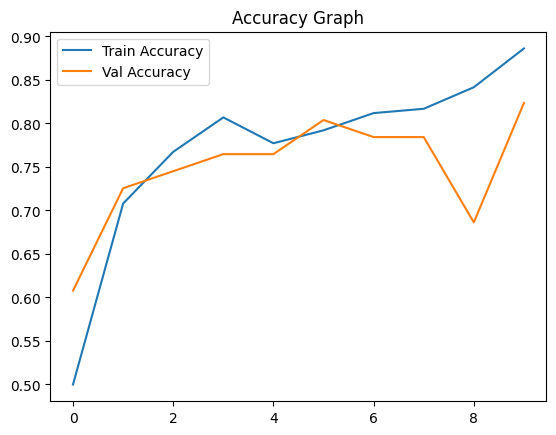

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [10]:
model.save("brain_tumor_model.h5")

In [11]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Image not found at {image_path}")
        return
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))
    
    prediction = model.predict(img)[0][0]
    
    if prediction > 0.5:
        print("Tumor Detected 🧠")
    else:
        print("No Tumor ✅")


In [12]:
# Example
predict_image("brain_tumor_dataset/yes/Y1.jpg")  # Tumor image
predict_image("brain_tumor_dataset/no/sample2no.jpg")   # No tumor image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Tumor Detected 🧠
Error: Image not found at brain_tumor_dataset/no/sample2no.jpg
